SGD Epoch 1
SGD Epoch 2
SGD Epoch 3
SGD Epoch 4
SGD Epoch 5
RMSProp Epoch 1
RMSProp Epoch 2
RMSProp Epoch 3
RMSProp Epoch 4
RMSProp Epoch 5
Adam Epoch 1
Adam Epoch 2
Adam Epoch 3
Adam Epoch 4
Adam Epoch 5


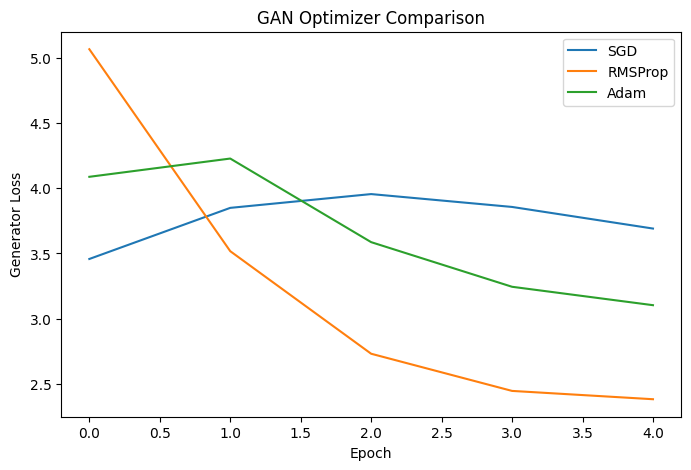

In [7]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Load MNIST Dataset
# -----------------------------------
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)

x_train = x_train[:10000]

BATCH_SIZE = 64

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(10000).batch(BATCH_SIZE)

# -----------------------------------
# Generator
# -----------------------------------
def build_generator():

    model = tf.keras.Sequential([

        layers.Input(shape=(100,)),

        layers.Dense(128, activation='relu'),

        layers.Dense(28 * 28, activation='sigmoid'),

        layers.Reshape((28,28,1))
    ])

    return model

# -----------------------------------
# Discriminator
# -----------------------------------
def build_discriminator():

    model = tf.keras.Sequential([

        layers.Input(shape=(28,28,1)),

        layers.Flatten(),

        layers.Dense(128, activation='relu'),

        layers.Dense(1, activation='sigmoid')
    ])

    return model

# -----------------------------------
# Train GAN
# -----------------------------------
def train_gan(optimizer_name):

    generator = build_generator()

    discriminator = build_discriminator()

    # Create NEW optimizer instances
    if optimizer_name == "SGD":

        d_optimizer = tf.keras.optimizers.SGD(
            learning_rate=0.01
        )

        g_optimizer = tf.keras.optimizers.SGD(
            learning_rate=0.01
        )

    elif optimizer_name == "RMSProp":

        d_optimizer = tf.keras.optimizers.RMSprop(
            learning_rate=0.0005
        )

        g_optimizer = tf.keras.optimizers.RMSprop(
            learning_rate=0.0005
        )

    else:

        d_optimizer = tf.keras.optimizers.Adam(
            learning_rate=0.0002
        )

        g_optimizer = tf.keras.optimizers.Adam(
            learning_rate=0.0002
        )

    discriminator.compile(
        optimizer=d_optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    discriminator.trainable = False

    gan_input = tf.keras.Input(shape=(100,))

    fake_image = generator(gan_input)

    gan_output = discriminator(fake_image)

    gan = tf.keras.Model(
        gan_input,
        gan_output
    )

    gan.compile(
        optimizer=g_optimizer,
        loss='binary_crossentropy'
    )

    d_losses = []
    g_losses = []

    EPOCHS = 5
    noise_dim = 100

    for epoch in range(EPOCHS):

        for real_images in dataset:

            batch_size = real_images.shape[0]

            # Generate fake images
            noise = np.random.normal(
                0, 1,
                (batch_size, noise_dim)
            )

            fake_images = generator.predict(
                noise,
                verbose=0
            )

            real_labels = np.ones((batch_size,1))
            fake_labels = np.zeros((batch_size,1))

            # Train discriminator
            discriminator.trainable = True

            discriminator.train_on_batch(
                real_images,
                real_labels
            )

            discriminator.train_on_batch(
                fake_images,
                fake_labels
            )

            # Train generator
            discriminator.trainable = False

            noise = np.random.normal(
                0,1,
                (batch_size, noise_dim)
            )

            g_loss = gan.train_on_batch(
                noise,
                real_labels
            )

        d_losses.append(0)
        g_losses.append(g_loss)

        print(f"{optimizer_name} Epoch {epoch+1}")

    return g_losses

# -----------------------------------
# Compare Optimizers
# -----------------------------------
optimizers = ["SGD", "RMSProp", "Adam"]

results = {}

for name in optimizers:

    g_loss = train_gan(name)

    results[name] = g_loss

# -----------------------------------
# Plot Results
# -----------------------------------
plt.figure(figsize=(8,5))

for name in results:

    plt.plot(
        results[name],
        label=name
    )

plt.title("GAN Optimizer Comparison")

plt.xlabel("Epoch")

plt.ylabel("Generator Loss")

plt.legend()

plt.show()